# Introduction

## The problem

The "news-vendor" problem is common name for an inventory optimization problem. Where some estimate of a products demand is known, and the goal is then to find the optimum number of stock to have of this item to maximize expected profit.

For example, lets say you are a Bakery and you need to decide how many muffins to bake for tomorrows customers. You know that typically you sell an average of 100 muffins with a standard deviation of 20. If we bake to many they go off and we loss money ( the amount it cost to make ), while if we bake to few we loss a potential sales ( and sometimes more importantly, the customers buy some where else and then do not come back, meaning we miss out of future sales).

Intuition tells us to bake 100 muffins, but as will be shown this is wrong. This also does not consider things like:

- What if we have multiple muffins, each with there own average sale amounts?
- What if we only have so much shelf space? Or only limited ingredients and budget?
- What if we bake 100, but typically only 90 or so are sellable and the rest are defects?

So how de we go about solving the problem?

## The "Average" Trap: Jensen's Inequality

When dealing with uncertainty, a common intuition is to use averages:
> *"If I on average sell 100 units, I should order 100 units to always meet average demand."*

This intuition is mathematically wrong and it leads to systematic profit loss.

The reason is Jensen's Inequality:
$$\mathbb{E}[f(X)] \le f(\mathbb{E}[X])$$
*(For any concave function $f$)*

In simpler terms: "The Average Profit is LESS than the Profit of the Average."

### Why it applies to Inventory
The News-vendor profit function is **Concave** (it looks like a hill).
- Upside is Capped: you can't sell more than demand.
- Downside is Uncapped: you can theoretically order infinite more than the demand.

Because of this asymmetry, the "Bad Luck" scenarios hurt you more than the "Good Luck" scenarios help you. By using the simple average (mean demand), you ignore this drag, overestimate your expected profit, and fail to order the necessary safety buffer.

### Code Example of Jensen's Inequality

In [1]:
import numpy as np

# Convex function
def f(x):
    return -(x - 1) ** 2 - 1

# Random variable X
X = np.random.normal(loc=1.0, scale=2.0, size=100000)

f_E = f(X.mean())  # function of the average
E_f = f(X).mean()  # average of the function

print(f"{E_f} <= {f_E}")

-4.997724803564405 <= -1.0000000505049003


## The Single Item Problem

The Single-Item problem is about balancing two financial risks: Overage (buying too much and wasting it) and Underage (buying too little and missing a sale). Let's use a fresh muffin to illustrate this.

### Problem Parameters 
First, we calculate the financial impact of being wrong. Lets pretend the muffin has the following parameters:
- Cost Price ($C$): 10
- Selling Price ($P$): 20
- Salvage Value ($S$): 5 (e.g., selling day-old muffins at a discount)

Underage Cost ($C_u$): This is the "pain" of turning a customer away because you ran out. It equals the lost profit. 
$$C_u = P - C = 20 - 10 = 10$$

Overage Cost ($C_o$):This is the "pain" of having a leftover muffin at the end of the day. It equals the net loss on that unit.
$$C_o = C - S = 10 - 5 = 5$$

### The Critical Fractile (The Target Probability)
We want to keep adding inventory as long as the expected gain of selling the next muffin ($C_u$) outweighs the expected loss of trashing it ($C_o$).The optimal service level (Critical Fractile) is the ratio of the "upside" to the "total risk":
$$CF = \frac{C_u}{C_u + C_o} = \frac{10}{10 + 5} = \frac{10}{15} \approx \mathbf{0.67}$$

### The Optimal Decision
This ratio ($0.67$) tells us exactly how aggressive to be. It says: "Order enough muffins so that there is a 67% chance you will satisfy all demand."Since $0.67 > 0.50$, you should order more than the average demand. Why? Because the profit from selling one muffin ($10$) is double the cost of wasting one ($5$). It is financially rational to risk a little waste to chase that high profit. If the costs were reversed (e.g., waste cost $10$, profit $5$), the ratio would be $0.33$, and you would order less than the average to play it safe.

## Code Example

Below we use the implemented classes to solve the problem. We create an `item` object as well as a `demand` object. We pass this to a solving class that calculates the optimum stock quantity.

In [2]:
from inventory_management.items import Item
from inventory_management.distributions.demand_distributions import NormalDemand
from inventory_management.solvers import SingleItemSolver

muffin = Item("muffin", cost_price=10, selling_price=20, salvage_value=5) # the item and its parameters

demand = NormalDemand(100, 20) # the expected demand 

opt_quantity = SingleItemSolver(muffin, demand).solve() # the solution

We can then use the plotting suite to view the problem

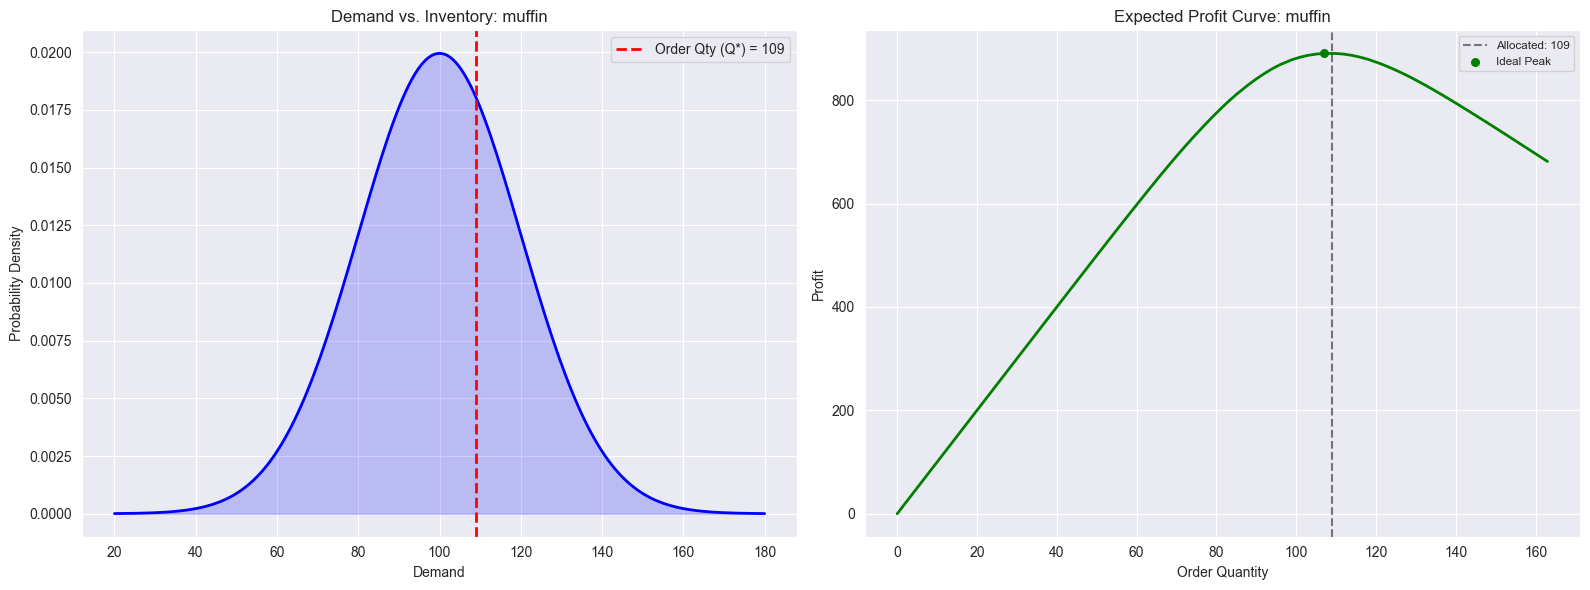

In [3]:
from inventory_management.plot_suite.single_item import plot_single_item_analysis

results = plot_single_item_analysis(muffin, demand, opt_quantity)

The expected profit plot illustrates why ordering more in this scenario is the better option. We can see the gradient of the line is steeper before the mean, meaning ordering less items results in a "quicker" decrease in profit than ordering more. We can test this by changing the selling price and recording the new optimum order quantity (this assumes that the demand from customers is independent from the selling price which is not reasonable, but useful to illustrate how the fractile works).

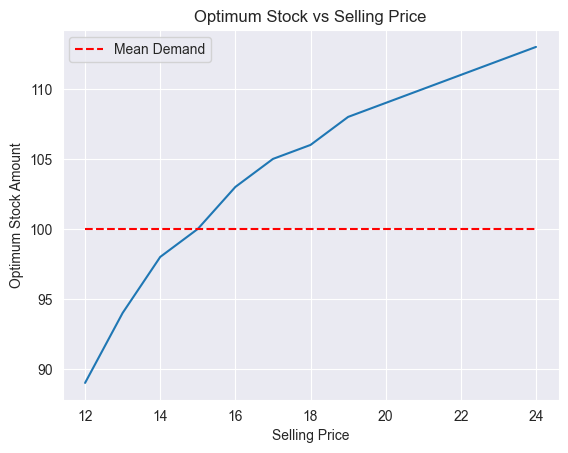

In [4]:
import numpy as np
import matplotlib.pyplot as plt

possible_sell_price = np.arange(12, 25, 1)
opt_stock = []
for sell_price in possible_sell_price:
    muffin = Item(
        "muffin", cost_price=10, selling_price=sell_price, salvage_value=5
    )  # the item and its parameters

    demand = NormalDemand(100, 20)  # the expected demand

    opt_stock.append(SingleItemSolver(muffin, demand).solve()) # the solution

plt.figure()
plt.plot(possible_sell_price, opt_stock)
plt.plot([12, 24], [100, 100], 'r--', label = "Mean Demand")
plt.legend()
plt.title("Optimum Stock vs Selling Price")
plt.ylabel("Optimum Stock Amount")
plt.xlabel("Selling Price")
plt.show()

We can see that when the selling price is 15, the best option is to order the mean demand. This is because the profit of selling a muffin is equal to the loss or salvage value of an unsold muffin, so the critical fractile becomes 0.5.

We can also notice how non-smooth the curve is. This is due to the fact that we cant order .5 of a muffin, so we have to round to the nearest integer.

## What Next

- Multi-item problem.
- Multi-item with single and multiple constraints.
- Items with yield distributions.

### Not yet covered:

- Substitutions: Customers will buy item B if item A is out of stock
- Customer Lifetime Value: Missing a new customer has the potential to miss all future orders as well.